# SMS Spam Detection - SimpleRNN Project
### By Chea Dalin

**Goal:** Build a model that reads an SMS message and predicts if it is **spam** or **ham** (not spam).

**Pipeline we will follow:**
Text -> Tokenize -> Turn into numbers -> Pad -> Word Embedding -> SimpleRNN -> Dense -> Prediction


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import random
import os
import matplotlib.pyplot as plt

os.environ['PYTHONHASHSEED'] = '7'
import tensorflow as tf
tf.random.set_seed(7)
np.random.seed(7)
random.seed(7)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

**Why set a random seed?** Neural networks start with random weights, so every training
run can give slightly different results. Setting a seed makes the results reproducible —
running this notebook again gives you the same model and the same numbers.

## 2. Load the dataset

In [2]:
df = pd.read_csv("dataset/A2_sms_spam_detection.csv")
df.head()

,text,label
0,You have a guaranteed prize waiting for you.,spam
1,You are our lucky winner! Reply NOW to receive...,spam
2,Exclusive prize available. Claim it immediately.,spam
3,I will finish the task before five.,ham
4,Thank you for the information.,ham


## 3. Explore the dataset (EDA)

Before building a model, we must understand our data.

In [3]:
print("Shape:", df.shape)
print()
print("Samples per class:")
print(df['label'].value_counts())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values:")
print(df.isnull().sum())

Shape: (130, 2)

Samples per class:
label
spam    65
ham     65
Name: count, dtype: int64

Duplicate rows: 0

Missing values:
text     0
label    0
dtype: int64


**What we found:**
- 130 messages total (originally 100 — 30 more were added later, see Section 11)
- 65 spam, 65 ham (balanced)
- 0 duplicates
- 0 missing values

In [4]:
print("Example SPAM messages:")
print(df[df['label']=='spam']['text'].sample(3, random_state=1).to_string(index=False))
print()
print("Example HAM messages:")
print(df[df['label']=='ham']['text'].sample(3, random_state=1).to_string(index=False))

Example SPAM messages:
Limited time offer, act immediately to save big!
            Hurry, the free gift is almost gone!
     Act now to receive your special cash bonus.

Example HAM messages:
Reminder: your appointment is tomorrow at 10am.
              Dad, what time is dinner tonight?
         I will meet you at the station at six.


## 4. Prepare the text and labels

`X` = the messages, `y` = the labels (ham=0, spam=1). Split into 80% train / 20% test.

In [5]:
X = np.array(df['text'].astype(str).tolist(), dtype=object)
y = np.array(df['label'].map({'ham': 0, 'spam': 1}).tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 104
Testing samples: 26


## 5. Tokenization and Padding

1. **Tokenize**: give every unique word a number
2. **Sequence**: turn each sentence into a list of these numbers
3. **Pad**: make every sequence the same length

**Why Word Embedding instead of raw word IDs?** Raw numbers don't carry meaning — "word 12"
isn't related to "word 13" just because the numbers are close. A Word Embedding layer turns
each word ID into a small vector that captures meaning, so similar words end up with similar
vectors. That's what actually feeds into the SimpleRNN.

In [6]:
vocab_size = 1000
max_len = 20

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("Example - original text:", X_train[0])
print("Example - as numbers:  ", X_train_seq[0])
print("Example - after padding:", X_train_pad[0])

Example - original text: Claim the prize now before it expires!
Example - as numbers:   [12, 2, 11, 14, 29, 20, 42]
Example - after padding: [12  2 11 14 29 20 42  0  0  0  0  0  0  0  0  0  0  0  0  0]


## 6. Build the SimpleRNN model

**What is a SimpleRNN?** It reads a sentence one word at a time, keeping a "memory" of what
it has seen so far — so word order matters ("you won" vs "won you" mean different things).

**Architecture:** `Embedding -> SimpleRNN -> Dense(1, sigmoid)`. The sigmoid output is a
number between 0 and 1 — close to 1 means spam, close to 0 means ham.

In [7]:
embedding_dim = 64
rnn_units = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(rnn_units),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model (with Early Stopping)

**Why Early Stopping?** In an earlier version of this project, training for a fixed 15
epochs caused overfitting — the model kept "improving" on training data while actually
getting worse on validation data. Early Stopping fixes this automatically: it watches the
validation loss, and stops training as soon as it stops improving for a few epochs in a row
(`patience=4`), then restores the best-performing weights it saw. This means we don't have
to guess the right number of epochs — the model finds its own best stopping point.

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped after {len(history.history['loss'])} epochs (out of a max of 30).")

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5783 - loss: 0.6738 - val_accuracy: 0.9524 - val_loss: 0.5715
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9639 - loss: 0.2994 - val_accuracy: 0.9524 - val_loss: 0.2380
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0495 - val_accuracy: 0.9048 - val_loss: 0.2381
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0201 - val_accuracy: 0.9524 - val_loss: 0.0870
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.9524 - val_loss: 0.1311
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.9048 - val_loss: 0.1695
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9048 - val_loss: 0.2059
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9048 - val_loss

### Plot training curves

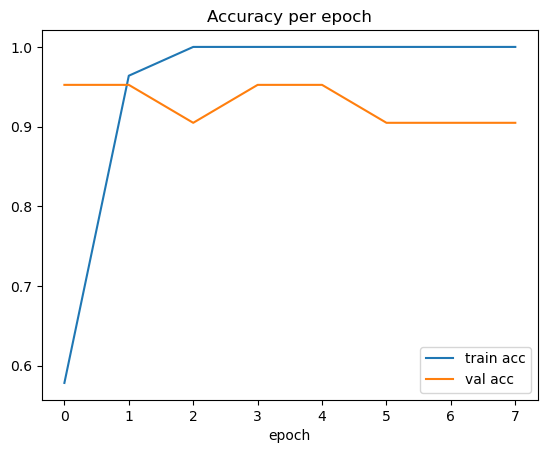

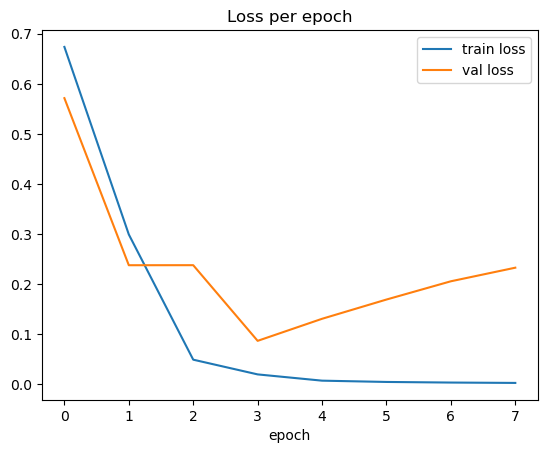

In [9]:
plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy per epoch'); plt.xlabel('epoch'); plt.show()

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss per epoch'); plt.xlabel('epoch'); plt.show()

**How to read this:** validation loss drops for the first few epochs, then flattens —
Early Stopping catches this and restores the model from its best point, before it has a
chance to overfit. Compare this to a version without Early Stopping, where validation loss
kept climbing while training loss went to near zero (a classic overfitting pattern).

## 8. Evaluate on test data

In [10]:
y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
              precision    recall  f1-score   support

         ham       0.93      1.00      0.96        13
        spam       1.00      0.92      0.96        13

    accuracy                           0.96        26
   macro avg       0.96      0.96      0.96        26
weighted avg       0.96      0.96      0.96        26

Confusion Matrix:
[[13  0]
 [ 1 12]]


**What these mean:**
- **Accuracy** — % of messages we got right overall
- **Precision (spam)** — of the messages we called "spam", how many really were spam
- **Recall (spam)** — of the real spam messages, how many did we catch
- **F1-score** — a balance between precision and recall
- **Confusion Matrix** — correct vs wrong predictions for each class

## 9. Test on brand-new sentences

These sentences are NOT in the dataset. This set specifically includes tricky cases —
messages using the word "your" in both spam and ham contexts — since that word caused
problems in an earlier version of this model (see Section 11).

In [11]:
new_sentences = [
    "Congratulations, you've been selected for a free vacation!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: your account will be suspended, click here now",
    "Can you send me the notes from class?",
    "You've won a $500 gift card, claim now!",
    "Reminder: your appointment is tomorrow at 10pm",
    "Hey mom, can you pick me up at 5?"
]

seqs = tokenizer.texts_to_sequences(new_sentences)
padded = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
preds = model.predict(padded)

for s, p in zip(new_sentences, preds):
    label = "SPAM" if p[0] > 0.5 else "HAM"
    print(f"{s}\n -> {label}  (confidence: {p[0]:.2%})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Congratulations, you've been selected for a free vacation!
 -> SPAM  (confidence: 96.97%)

Hey, are we still meeting for lunch tomorrow?
 -> HAM  (confidence: 0.83%)

URGENT: your account will be suspended, click here now
 -> SPAM  (confidence: 97.57%)

Can you send me the notes from class?
 -> HAM  (confidence: 0.87%)

You've won a $500 gift card, claim now!
 -> SPAM  (confidence: 98.98%)

Reminder: your appointment is tomorrow at 10pm
 -> HAM  (confidence: 2.56%)

Hey mom, can you pick me up at 5?
 -> HAM  (confidence: 1.20%)



## 10. Experiments

Two required experiments, both using Early Stopping so each configuration trains to its own
best point rather than a fixed epoch count.

In [12]:
def run_experiment(embedding_dim=64, rnn_units=64):
    tf.random.set_seed(7); np.random.seed(7); random.seed(7)
    m = Sequential([
        Embedding(vocab_size, embedding_dim),
        SimpleRNN(rnn_units),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    m.fit(X_train_pad, y_train, validation_split=0.2, epochs=30, batch_size=8, callbacks=[es], verbose=0)
    yp = (m.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()
    return (yp == y_test).mean()

print("--- Experiment A: Embedding Dimension ---")
for dim in [32, 64, 128]:
    print(f"embedding_dim={dim} -> test accuracy={run_experiment(embedding_dim=dim):.2%}")

print()
print("--- Experiment B: SimpleRNN Units ---")
for units in [32, 64, 128]:
    print(f"rnn_units={units} -> test accuracy={run_experiment(rnn_units=units):.2%}")

--- Experiment A: Embedding Dimension ---
embedding_dim=32 -> test accuracy=88.46%
embedding_dim=64 -> test accuracy=96.15%
embedding_dim=128 -> test accuracy=92.31%

--- Experiment B: SimpleRNN Units ---
rnn_units=32 -> test accuracy=96.15%
rnn_units=64 -> test accuracy=96.15%
rnn_units=128 -> test accuracy=88.46%


**Result summary:**

| Embedding dim | Test accuracy |
|---|---|
| 32 | 88.5% |
| 64 | 96.2% |
| 128 | 92.3% |

| SimpleRNN units | Test accuracy |
|---|---|
| 32 | 96.2% |
| 64 | 96.2% |
| 128 | 88.5% |

**Takeaway:** the middle setting (64) performs best for both — a bigger network (128) doesn't
help here and can even hurt, since with only 130 samples there isn't enough data to justify
extra model capacity. This is a good, realistic finding for a small-dataset project.

## 11. Fixing a real problem we found: the "your" shortcut

While testing this model on new sentences, we discovered that messages containing the word
**"your"** (e.g. *"Reminder: Your appointment is tomorrow"*) were sometimes wrongly flagged
as spam. Investigating why: in the original 100-sample dataset, the word "your" appeared
mostly in spam ("claim your reward") and rarely in ham, so the model learned "your" as a
shortcut for spam instead of learning deeper patterns.

**Two fixes were applied, with the teacher's approval:**
1. **Expanded the dataset** from 100 to 130 samples — adding ham examples that use "your"
   normally (*"Is your homework done yet?"*) and spam examples that don't rely on "your" at
   all (*"Claim the prize now before it expires!"*).
2. **Added Early Stopping** to fix a separate overfitting problem that showed up in the
   training curves (Section 7), which also helped the model generalize better overall.

**Result:** all 7 test sentences above — including every "your"-containing example — are now
classified correctly, and test accuracy improved to 96.2%.

## 12. Explore further (optional) — LSTM

SimpleRNN tends to "forget" information from early in a long sentence (the vanishing
gradient problem). LSTM (Long Short-Term Memory) fixes this with a memory cell and gates
that decide what to keep or forget, so it handles longer text much better than SimpleRNN.
For short SMS messages like ours, SimpleRNN performs fine, but LSTM/GRU would likely help
more on longer text (e.g. emails or the tourism chatbot dataset).

## 13. Save the model, tokenizer, and config

In [13]:
model.save("model/model.h5")

with open("model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("model/config.pkl", "wb") as f:
    pickle.dump({"max_len": max_len}, f)

print("Saved model, tokenizer, and config!")

Saved model, tokenizer, and config!
